## Loss Function & Optimizer in Deep Learning

Let me build this up from the ground up with simple analogies.

---

### The Big Picture

Imagine you're teaching a child to throw a ball into a basket. After each throw:
1. You measure **how far off** the ball landed (→ **Loss Function**)
2. You **adjust their technique** based on the error (→ **Optimizer**)

That's exactly what happens in deep learning.

---

## 🎯 Loss Function

### What is it?
A loss function measures **how wrong your model's predictions are**. It gives a single number — the lower it is, the better your model is doing.

### Intuition
| Prediction | Actual | Loss (Error) |
|---|---|---|
| 9 | 10 | Small |
| 2 | 10 | Large |
| 10 | 10 | Zero (perfect!) |

### Common Loss Functions

**1. Mean Squared Error (MSE)** — for regression
```
Loss = average of (predicted - actual)²
```
Punishes big errors heavily because of the square. Used when predicting continuous values like house prices.

**2. Binary Cross-Entropy** — for yes/no classification
```
Loss = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
```
Used when output is 0 or 1 (spam/not spam, cat/not cat).

**3. Categorical Cross-Entropy** — for multi-class classification
```
Loss = -Σ yᵢ · log(ŷᵢ)
```
Used when classifying into multiple categories (dog/cat/bird).

**4. Huber Loss** — robust regression
Combines MSE and MAE — less sensitive to outliers than MSE.

---

## ⚙️ Optimizer

### What is it?
An optimizer uses the loss value to **update the model's weights** so it makes better predictions next time. It answers: *"In which direction and by how much should I adjust?"*

### The key concept: Gradient Descent

Think of being blindfolded on a hilly landscape, trying to reach the lowest valley (minimum loss). You feel the slope under your feet and take a step downhill. That's **gradient descent**.

```
new_weight = old_weight - learning_rate × gradient
```

The **gradient** = direction of steepest increase in loss
The **learning rate** = how big a step you take

---

### Types of Optimizers (Simple → Advanced)

**1. Vanilla Gradient Descent (BGD)**
- Looks at the *entire dataset* before updating weights
- Slow and memory-heavy, but stable
- Rarely used in practice for large datasets

**2. Stochastic Gradient Descent (SGD)**
- Updates weights after *every single sample*
- Fast but noisy — takes erratic steps
- Can escape local minima due to noise

**3. Mini-Batch Gradient Descent**
- Updates after a *small batch* (e.g., 32 samples)
- Best of both worlds — most common in practice

**4. SGD with Momentum**
- Adds a "memory" of past gradients — like a ball rolling downhill gaining speed
- Smooths out noisy updates, speeds up learning
```
velocity = β × velocity + gradient
weight -= learning_rate × velocity
```

**5. AdaGrad**
- Adapts the learning rate *per parameter*
- Rare features get bigger updates; frequent ones get smaller
- Problem: learning rate shrinks to near-zero over time

**6. RMSProp**
- Fixes AdaGrad's shrinking problem using a moving average of squared gradients
- Great for RNNs and non-stationary problems

**7. Adam (Adaptive Moment Estimation)** ⭐ Most Popular
- Combines **Momentum** + **RMSProp**
- Maintains both a moving average of gradients and squared gradients
- Self-corrects learning rates per parameter
- Works great out of the box for most problems
```
m = β₁·m + (1-β₁)·gradient        ← momentum term
v = β₂·v + (1-β₂)·gradient²       ← RMSProp term
weight -= lr · m / (√v + ε)
```

**8. AdamW**
- Adam + proper **weight decay** (L2 regularization)
- Preferred for transformers (GPT, BERT)

**9. Lion, Sophia, Adan** (cutting-edge)
- Newer optimizers designed for large language models
- Lion uses sign-based updates — faster and more memory-efficient than Adam

---

## 🔗 How They Work Together

```
Forward Pass → Prediction
      ↓
Loss Function → measures error
      ↓
Backpropagation → computes gradients
      ↓
Optimizer → updates weights
      ↓
Repeat until loss is minimized
```

---

## Quick Reference Cheat Sheet

| Task | Recommended Loss | Recommended Optimizer |
|---|---|---|
| Regression | MSE / Huber | Adam |
| Binary Classification | Binary Cross-Entropy | Adam |
| Multi-class | Categorical Cross-Entropy | Adam / AdamW |
| NLP / Transformers | Cross-Entropy | AdamW |
| RL / Custom | Custom | RMSProp / Adam |

---

### The Golden Rule
> A good **loss function** tells the model *what* to optimize. A good **optimizer** tells it *how* to get there efficiently.

Want me to go deeper on any specific part — like backpropagation, learning rate schedules, or a coding example in PyTorch/Keras?

**Batch Gradient Descent:** so far we were updating the weight on basis of complete data load /read thats batch gradient descent.

We normally dont use Batch Gradient Descent because

1)Memory Ineffecient : specially we are dealing with image or  text because of large size.

2)Convergence : Dont get better convergence because parameter gets updated after complete load

**Stochastic Gradient Descent:** update the parameter after each row

**Mini Batch Gradient Descent:** update after every small sample size of 32/64 rows etc. and widely accepted.




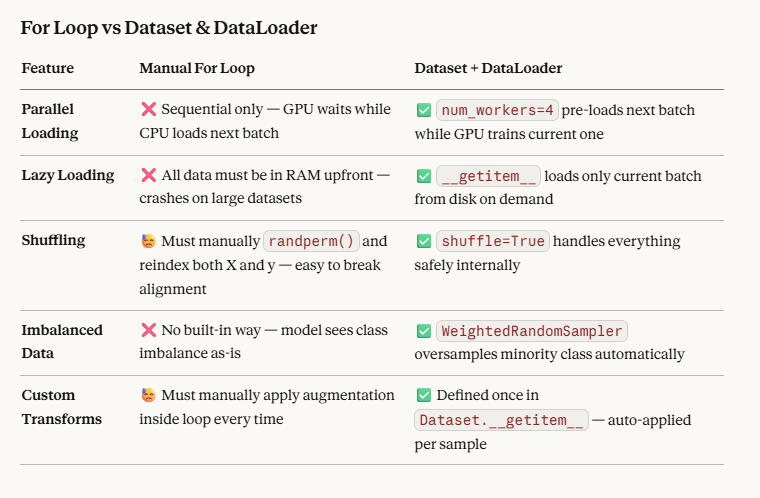

**Dataset Class:** it defines how we are going to access the data and this class has three important methods.


1.   __init__: it defines how data will be loaded from which folder/file
2.   __len__: it takes the sample size to identify the number of batches
3.   __getitem__: returns teh data at given index


**DataLoader Class:**


1.   at the start of epoch it shuffles the indeces of data.
2.   divides the indices into chunks of batch_size
3.   Now , send the indices to Dataset Class specially __getitem__ method.
4. samples collected and combined into a batch using collate_fn
5. once done then send batch to training loop










In [ ]:
from sklearn.datasets import make_classification


In [ ]:
import torch

In [ ]:
# creating synthetic Datasets
x,y=make_classification(
      n_samples=10, # random sample
      n_features=2, # of columns
      n_classes=2, # of output categories
      n_informative=2,
      n_redundant=0,
      random_state=42
)

In [ ]:
x=torch.from_numpy(x).float()
y=torch.from_numpy(y).float()

In [ ]:
from torch.utils.data import Dataset,DataLoader

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=features
    self.labels=labels

  def __len__(self):
    return len(self.labels)

  def __getitem__(self,idx):
    """ In this we can apply any kind of transformation related to data
        for image data, resize, converting to black & white , augmentation
        for text data, converting to lower case, stop word removal , lemmatization"""
    return self.features[idx],self.labels[idx]

In [ ]:
dataset=CustomDataset(x,y)

In [ ]:
len(dataset)

10

In [ ]:
## Data Loader
dataloader=DataLoader(dataset,batch_size=2,shuffle=True)

In [ ]:
for batch_feature,batch_labels in dataloader:
  print(batch_feature)
  print(batch_labels)
  print('*'*50)

tensor([[-2.8954,  1.9769],
        [-0.5872, -1.9717]])
tensor([0., 0.])
**************************************************
tensor([[ 1.7273, -1.1858],
        [ 1.0683, -0.9701]])
tensor([1., 1.])
**************************************************
tensor([[-0.7206, -0.9606],
        [ 1.7774,  1.5116]])
tensor([0., 1.])
**************************************************
tensor([[ 1.8997,  0.8344],
        [-1.1402, -0.8388]])
tensor([1., 0.])
**************************************************
tensor([[-0.9382, -0.5430],
        [-1.9629, -0.9923]])
tensor([1., 0.])
**************************************************


**Sampler**

dataloader have sampler to shuffle the data.
  
  👉 shuffle=True in DataLoader: internally uses RandomSampler

👉 shuffle=False: uses SequentialSampler # means no shuffling specially used in time series data

Apart form this we can create custom sampler, ex: strata

**Collate_fn**
*  defines how individual samples are combined into a batch.
* Needed when inputs have different sizes (e.g., text sequences).
* It applies custom logic like **padding** to make shapes equal.
* **Example:** `[1,2,3]` and `[4,5]` → after `collate_fn` → `[[1,2,3],[4,5,0]]` ready for batching.



**Parallel Processing**

So far we are doing the steps sequentially however we can do in parallel to leverage , we have worker parameter in dataloader class.

Here’s a **concise explanation of all 8 DataLoader parameters (2 lines each)** 👇

---

**1. dataset**

* The source from which DataLoader reads data.
* Must implement `__getitem__()` and `__len__()` methods.

---

**2. batch_size**

* Number of samples processed in one iteration.
* Larger batch = faster training but higher memory usage.

---

**3. shuffle**

* Randomizes data order every epoch if set to True.
* Helps avoid model learning sequence patterns.

---

**4. num_workers**

* Number of CPU processes used for loading data.
* Higher value speeds up loading (useful for large datasets).

---

**5. pin_memory**

* Moves data to pinned (page-locked) memory before GPU transfer.
* Speeds up CPU → GPU data transfer (useful with CUDA).

---

**6. drop_last**

* Drops the last batch if it’s smaller than batch_size.
* Useful when consistent batch size is required.

---

**7. collate_fn**

* Defines how individual samples are combined into a batch.
* Used for padding or custom batching logic (e.g., NLP).

---

**8. sampler**

* Controls how data points are selected (order/strategy).
* Useful for shuffling, balancing, or custom sampling logic.



In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('diagnosis',axis=1),df['diagnosis'],test_size=0.2,random_state=42)



In [ ]:
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train) # Fit used to learn the mean and standard deviation and transform applies the scalar formula (x-mu)/sigma
                                  #output is NumPy array
x_test=scalar.transform(x_test) # it uses the mean  and sigma created for learning dataset to transform test.

In [ ]:
y_train=LabelEncoder().fit_transform(y_train) #label encoder assign the numbers 0,1,2 etc. if value has 3 values then it will assign 0,1,2 which creates ordinal data
                                            # one Hot encoder creates dummy variable
y_test=LabelEncoder().fit_transform(y_test)

In [ ]:
#Converting numpy to tensor
x_train_tensor=torch.from_numpy(x_train).float()
y_train_tensor=torch.from_numpy(y_train).float()
x_test_tensor=torch.from_numpy(x_test).float()
y_test_tensor=torch.from_numpy(y_test).float()


In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=features
    self.labels=labels

  def __len__(self):
    return len(self.labels)

  def __getitem__(self,idx):
    """ In this we can apply any kind of transformation related to data
        for image data, resize, converting to black & white , augmentation
        for text data, converting to lower case, stop word removal , lemmatization"""
    return self.features[idx],self.labels[idx]

In [ ]:
train_data=CustomDataset(x_train_tensor,y_train_tensor)
test_data=CustomDataset(x_test_tensor,y_test_tensor)

In [ ]:
train_loader= DataLoader(train_data,batch_size=32,shuffle=True)
test_loader= DataLoader(test_data,batch_size=32,shuffle=False)


In [ ]:
import torch
import torch.nn as nn

class Model(nn.Module): # inherit from this class
  def __init__(self,num_features): # it defines the model and no data has passed yet
    super().__init__()
    self.container=nn.Sequential( # it defines the sequential network/container
                                  #Stacks layers in order (one after another)
        nn.Linear(num_features,3), #it defines the weights
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid())

  def forward(self,features): # t runs the model
    out=self.container(features)
    return out


In [ ]:
learning_rate=0.1
epoch=25

In [ ]:
##Creating model

model=Model(x_train_tensor.shape[1])

#defining optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

# define loss function
loss_function = nn.BCELoss()



In [ ]:

#creating a loop
for epoch in range(epoch):
  for x_train_batch,y_train_batch in train_loader:
    #forward pass
    y_pred=model(x_train_batch)

    #loss function
    loss=loss_function(y_pred,y_train_batch.reshape(-1,1))

    #Clear Gradient
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    #Parameter Update
    optimizer.step()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 1, Loss: 0.033839043229818344
Epoch: 2, Loss: 0.03708382323384285
Epoch: 3, Loss: 0.007336765993386507
Epoch: 4, Loss: 0.00920645147562027
Epoch: 5, Loss: 0.1952255666255951
Epoch: 6, Loss: 0.018398866057395935
Epoch: 7, Loss: 0.06613308936357498
Epoch: 8, Loss: 0.16987013816833496
Epoch: 9, Loss: 0.03432973101735115
Epoch: 10, Loss: 0.017753224819898605
Epoch: 11, Loss: 0.18733538687229156
Epoch: 12, Loss: 0.004409649409353733
Epoch: 13, Loss: 0.008944126777350903
Epoch: 14, Loss: 0.014429866336286068
Epoch: 15, Loss: 0.036467548459768295
Epoch: 16, Loss: 0.01582738198339939
Epoch: 17, Loss: 0.013252626173198223
Epoch: 18, Loss: 0.003064980497583747
Epoch: 19, Loss: 0.0077019729651510715
Epoch: 20, Loss: 0.0019722753204405308
Epoch: 21, Loss: 0.0031574189197272062
Epoch: 22, Loss: 0.06305018812417984
Epoch: 23, Loss: 0.019135791808366776
Epoch: 24, Loss: 0.022874709218740463


In [ ]:
with torch.no_grad():
  y_pred=model.forward(x_test_tensor)
  y_pred_r=(y_pred > 0.50).float()
  accuracy=(y_pred_r==y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.5323176383972168
